# Calculation of upper and lower envelope variables

The upper and lower envelope variables describe the maximum and minimum values of a time-varying signal (such as a joint angle, force, or marker trajectory) over a specific period, typically a gait cycle.
The upper envelope traces the local maxima, while the lower envelope traces the local minima of the signal. These envelopes are useful for quantifying the range and variability of biomechanical signals, identifying outliers, and comparing movement patterns across subjects or conditions.

## Calculating upper and lower envelope for Joint angles:

We will find the peaks and troughs of normalized joint angle time series and will interpolate them to get a smooth envelope.
point-value metrics can be calculated from the envelope. i.e. the maximum, minimum, mean, etc...

In [1]:
from core.matlab_data_loader import MatlabDataLoader
import kineticstoolkit as ktk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, envelope, hilbert
from scipy.interpolate import interp1d

In [2]:
loader = MatlabDataLoader()

first_session_id = loader.get_successful_sessions()[0]
print("First session id: ", first_session_id)

L_KNEE_MARKER = "L_shank_1"
L_KNEE_JOINT = "L_knee"

# Raw
l_shank_1_marker_data = loader.get_marker_data(first_session_id, L_KNEE_MARKER)
l_knee_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=False)
l_knee_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=False)

# Normalised
l_knee_normalized_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=True)
l_knee_normalized_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=True)

First session id:  100001_20110531T161051


In [3]:
print("L_knee normalized velocity data shape:", l_knee_normalized_velocity_data.shape)
print("\nFirst few rows:")
print(l_knee_normalized_velocity_data.head())
print("\nData info:")
print(l_knee_normalized_velocity_data.info())

print("\nL_knee velocity data shape:", l_knee_velocity_data.shape)
print("\nFirst few rows:")
print(l_knee_velocity_data.head())
print("\nData info:")
print(l_knee_velocity_data.info())

L_knee normalized velocity data shape: (101, 4)

First few rows:
   PercentGaitCycle  X_deg_per_s  Y_deg_per_s  Z_deg_per_s
0          0.990099   -39.939151   -47.358481   -37.319925
1          1.980198   -40.040889   -49.539008   -37.851551
2          2.970297   -39.880153   -49.979782   -37.639577
3          3.960396   -38.802923   -49.926378   -35.880788
4          4.950495   -37.388509   -49.168112   -33.470496

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PercentGaitCycle  101 non-null    float64
 1   X_deg_per_s       101 non-null    float64
 2   Y_deg_per_s       101 non-null    float64
 3   Z_deg_per_s       101 non-null    float64
dtypes: float64(4)
memory usage: 3.3 KB
None

L_knee velocity data shape: (3999, 4)

First few rows:
   TimeIndex  X_deg_per_s  Y_deg_per_s  Z_deg_per_s
0          1  -100.824628     

In [4]:
def get_envelope_signal_via_peaks(signal_1d, type: str):
    """
    Calculate upper or lower envelope of a 1D signal using peak detection and interpolation.
    
    Args:
        signal_1d: 1D array of signal values
        type: 'upper' for upper envelope, 'lower' for lower envelope
    
    Returns:
        envelope_signal: interpolated envelope signal
    """
    if type == "upper":
        # FIXED: find_peaks returns a tuple (peaks, properties), we need only the indices
        peak_indices, _ = find_peaks(signal_1d)
    elif type == "lower":
        # FIXED: find_peaks returns a tuple (peaks, properties), we need only the indices
        peak_indices, _ = find_peaks(-signal_1d)
    else:
        raise ValueError("Invalid type. Must be 'upper' or 'lower'.")

    t = np.linspace(0, 100, len(signal_1d))
    
    # Handle edge cases where no peaks are found
    if len(peak_indices) == 0:
        # No peaks found - return constant envelope
        if type == "upper":
            return np.full_like(signal_1d, np.max(signal_1d))
        else:
            return np.full_like(signal_1d, np.min(signal_1d))
    
    elif len(peak_indices) == 1:
        # Only one peak - return constant envelope at that value
        return np.full_like(signal_1d, signal_1d[peak_indices[0]])
    
    else:
        # Multiple peaks - interpolate between them
        # FIXED: Use peak_indices instead of values (which was the full tuple)
        interpolator = interp1d(t[peak_indices], signal_1d[peak_indices], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        envelope_signal = interpolator(t)
        
        return envelope_signal

def get_envelope_metrics(signal_1d, function = get_envelope_signal_via_peaks):
    upper_envelope = function(signal_1d, type="upper")
    lower_envelope = function(signal_1d, type="lower")
    amplitude = upper_envelope - lower_envelope

    return{
        "upper_envelope_signal": upper_envelope,
        "lower_envelope_signal": lower_envelope,
        "amplitude_signal": amplitude,
        "mean_upper": np.mean(upper_envelope),
        "mean_lower": np.mean(lower_envelope),
        "mean_amplitude": np.mean(amplitude),
        "max_upper": np.max(upper_envelope),
        "max_lower": np.max(lower_envelope),
        "max_amplitude": np.max(amplitude),
    }

In [5]:
angles_velocity_data = {
    "Normalized Velocity": {
        "t": l_knee_normalized_velocity_data['PercentGaitCycle'].values,
        "x": l_knee_normalized_velocity_data['X_deg_per_s'].values,
        "y": l_knee_normalized_velocity_data['Y_deg_per_s'].values,
        "z": l_knee_normalized_velocity_data['Z_deg_per_s'].values
    },
    "Raw Velocity": {
        "t": l_knee_velocity_data['TimeIndex'].values,
        "x": l_knee_velocity_data['X_deg_per_s'].values,
        "y": l_knee_velocity_data['Y_deg_per_s'].values,
        "z": l_knee_velocity_data['Z_deg_per_s'].values
    },
    "Normalized Angle": {
        "t": l_knee_normalized_angle_data['PercentGaitCycle'].values,
        "x": l_knee_normalized_angle_data['X_deg'].values,
        "y": l_knee_normalized_angle_data['Y_deg'].values,
        "z": l_knee_normalized_angle_data['Z_deg'].values
    },
    "Raw Angle": {
        "t": l_knee_angle_data['TimeIndex'].values,
        "x": l_knee_angle_data['X_deg'].values,
        "y": l_knee_angle_data['Y_deg'].values,
        "z": l_knee_angle_data['Z_deg'].values
    }
}

In [6]:
def plot_signal_with_envelopes(
    x_axis,
    signal,
    upper_envelope,
    lower_envelope,
    *,
    axis_name="Signal",
    color="blue",
    x_label="X",
    y_label=None,
    title=None,
    ax=None
):
    """
    Plot a signal with its upper and lower envelopes, amplitude fill
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 4))

    # Plot original signal
    ax.plot(x_axis, signal, color=color, alpha=0.6, linewidth=1.5, label='Original Signal')

    # Plot envelopes
    ax.plot(x_axis, upper_envelope, color='red', linewidth=2, label='Upper Envelope')
    ax.plot(x_axis, lower_envelope, color='green', linewidth=2, label='Lower Envelope')

    # Fill amplitude area
    ax.fill_between(x_axis, lower_envelope, upper_envelope, alpha=0.2, color='purple', label='Amplitude')

    # Set labels and title
    ax.set_title(title or f'{axis_name} with Envelopes', fontweight='bold')
    ax.set_xlabel(x_label)
    if y_label is None:
        y_label = f'{axis_name} Value'
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(True, alpha=0.3)

    if ax is None:
        plt.tight_layout()
        plt.show()

    return ax


Testing envelope funciton using peaks...
Normalized Velocity x-axis mean_upper: 9.029145436725056
Normalized Velocity x-axis mean_lower: 20.317697045400188
Normalized Velocity x-axis mean_amplitude: -11.288551608675126
Normalized Velocity x-axis max_upper: 38.52278975248923
Normalized Velocity x-axis max_lower: 137.870615118177
Normalized Velocity x-axis max_amplitude: 44.671060615635156


Raw Velocity x-axis mean_upper: 55.924887734298366
Raw Velocity x-axis mean_lower: -48.137917885050896
Raw Velocity x-axis mean_amplitude: 104.06280561934928
Raw Velocity x-axis max_upper: 218.523768891657
Raw Velocity x-axis max_lower: 74.50277398209198
Raw Velocity x-axis max_amplitude: 272.94334273639436


Normalized Angle x-axis mean_upper: -5.58944962154782
Normalized Angle x-axis mean_lower: -7.8651805231848
Normalized Angle x-axis mean_amplitude: 2.27573090163698
Normalized Angle x-axis max_upper: -5.58944962154782
Normalized Angle x-axis max_lower: -7.8651805231848
Normalized Angle x-axis max

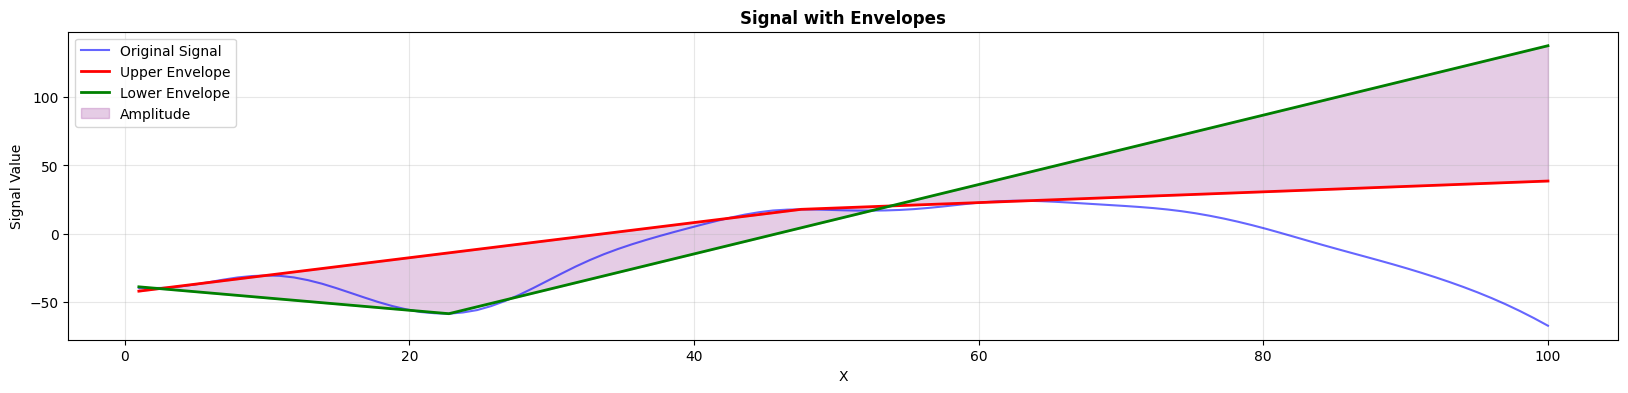

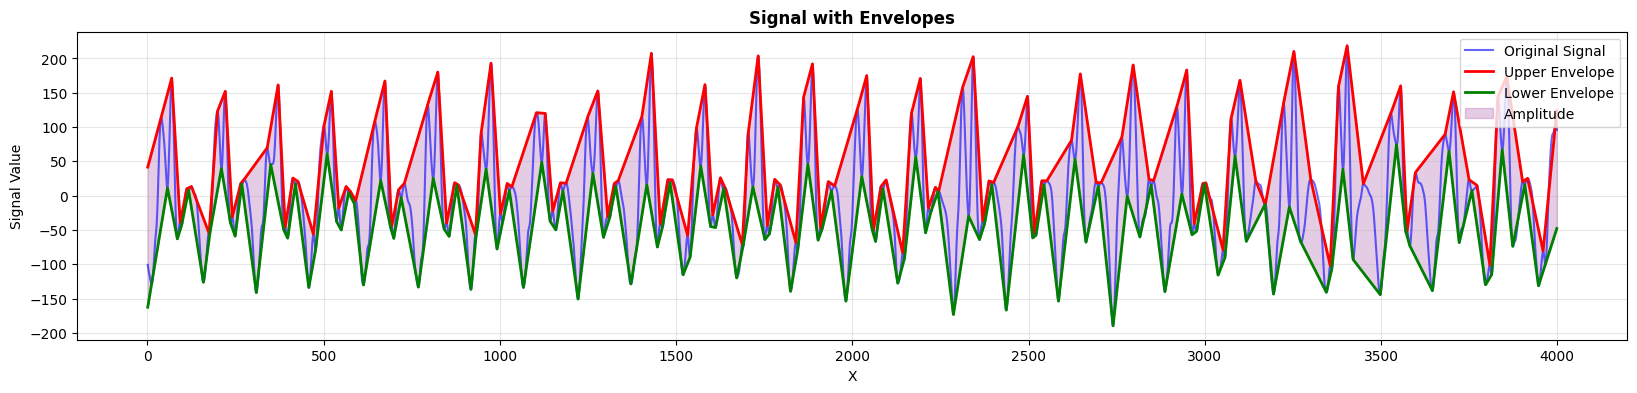

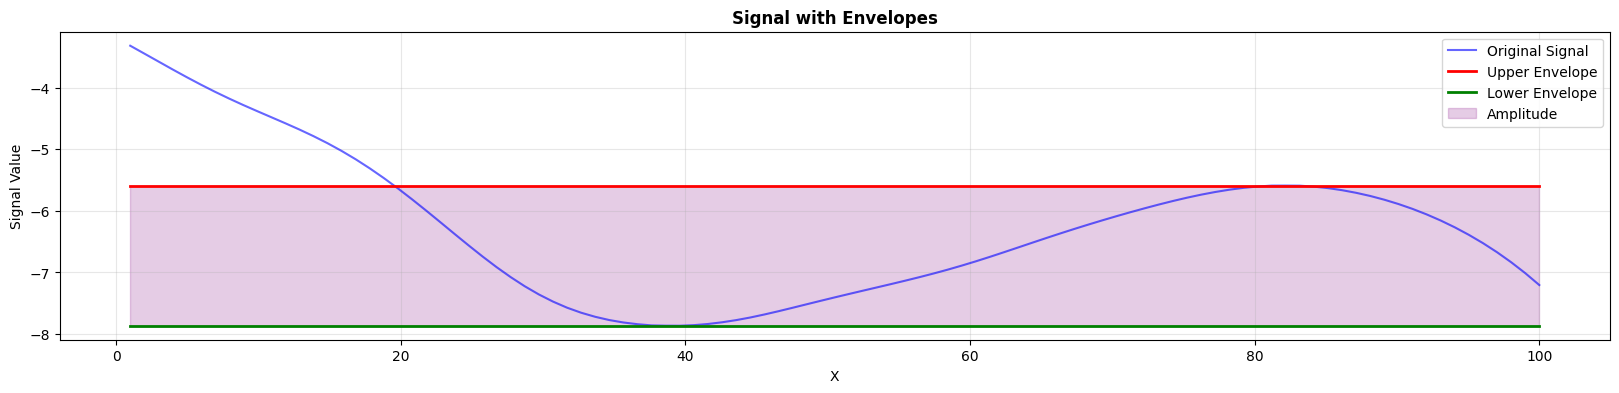

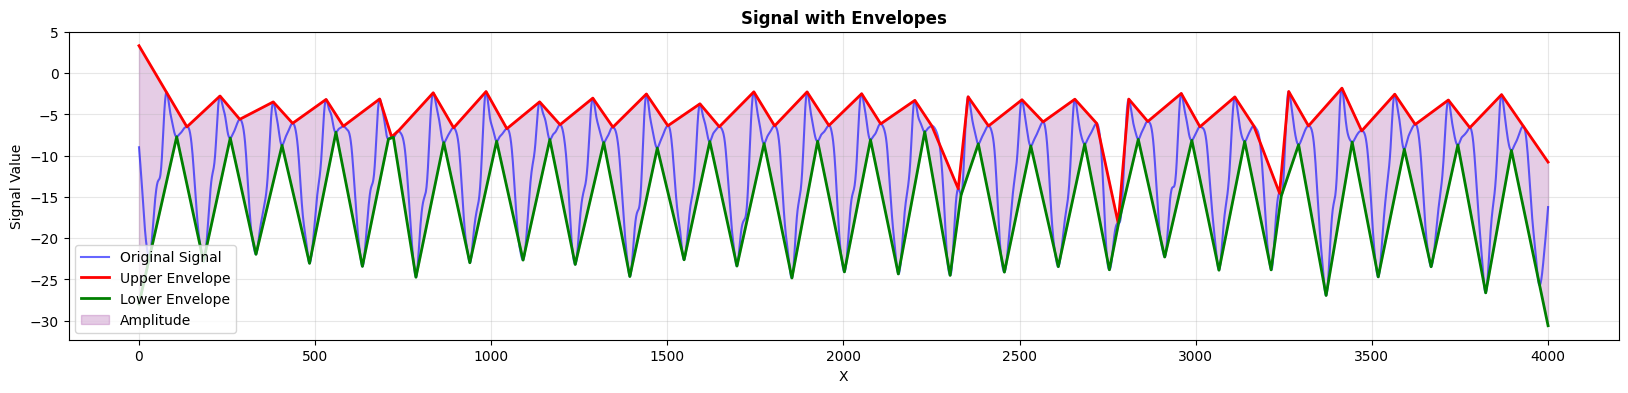

In [7]:
print("Testing envelope funciton using peaks...")

for dataset, data in angles_velocity_data.items():
    envelope_metrics = get_envelope_metrics(data["x"], function=get_envelope_signal_via_peaks)
    for metric, value in envelope_metrics.items():
        if metric not in ["upper_envelope_signal", "lower_envelope_signal", "amplitude_signal"]:
            print(f"{dataset} x-axis {metric}: {value}")
    plot_signal_with_envelopes(data["t"], data["x"], envelope_metrics["upper_envelope_signal"], envelope_metrics["lower_envelope_signal"])
    print("\n")

In [8]:
from scipy.signal import hilbert

def get_envelope_signal_hilbert(signal_1d, type: str):
    """
    Calculate upper or lower envelope using Hilbert transform for smooth curves.
    
    The Hilbert transform provides the analytical signal, from which we can extract
    a smooth envelope that follows the signal's amplitude modulation.
    
    Args:
        signal_1d: 1D array of signal values
        type: 'upper' for upper envelope, 'lower' for lower envelope
    
    Returns:
        envelope_signal: smooth envelope signal using Hilbert transform
    """
    if type == "upper":
        # For upper envelope, use the magnitude of the analytical signal
        analytical_signal = hilbert(signal_1d)
        envelope = np.abs(analytical_signal)
        return envelope
        
    elif type == "lower":
        # For lower envelope, invert signal, get envelope, then invert back
        analytical_signal = hilbert(-signal_1d)
        envelope = -np.abs(analytical_signal)
        return envelope
        
    else:
        raise ValueError("Invalid type. Must be 'upper' or 'lower'.")


Testing envelope funciton using hilbert...
Normalized Velocity x-axis mean_upper: 40.39807460762651
Normalized Velocity x-axis mean_lower: -40.39807460762651
Normalized Velocity x-axis mean_amplitude: 80.79614921525302
Normalized Velocity x-axis max_upper: 67.77489114473657
Normalized Velocity x-axis max_lower: -20.7940135423851
Normalized Velocity x-axis max_amplitude: 135.54978228947314


Raw Velocity x-axis mean_upper: 95.37242808675677
Raw Velocity x-axis mean_lower: -95.37242808675677
Raw Velocity x-axis mean_amplitude: 190.74485617351354
Raw Velocity x-axis max_upper: 264.7015965868708
Raw Velocity x-axis max_lower: -2.1096492058723757
Raw Velocity x-axis max_amplitude: 529.4031931737416


Normalized Angle x-axis mean_upper: 6.367905279412682
Normalized Angle x-axis mean_lower: -6.367905279412682
Normalized Angle x-axis mean_amplitude: 12.735810558825364
Normalized Angle x-axis max_upper: 8.078354890868768
Normalized Angle x-axis max_lower: -3.609536673622305
Normalized Angle x-a

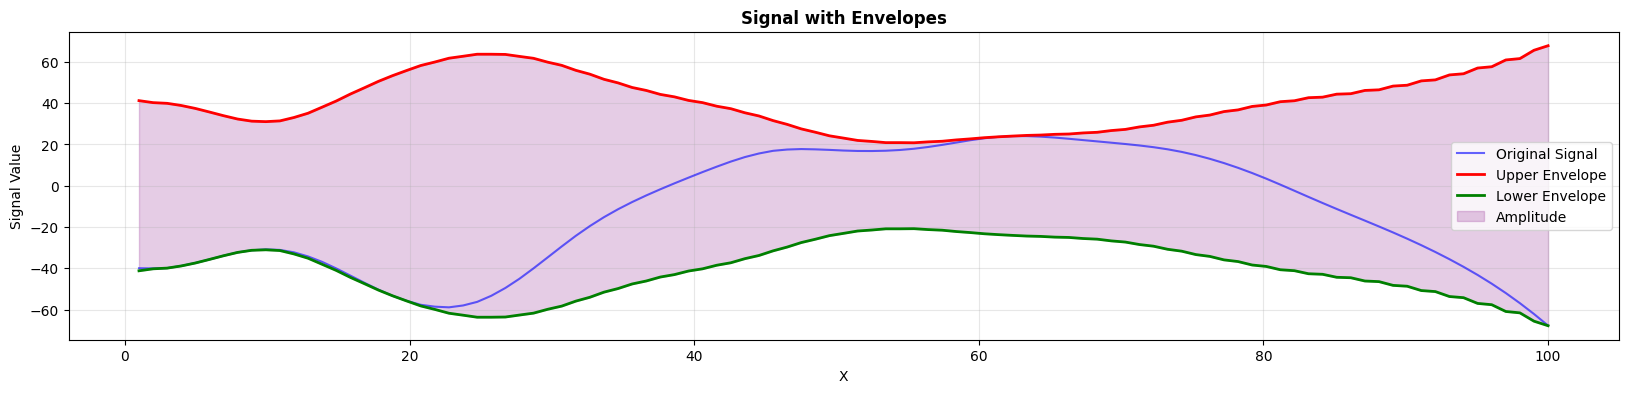

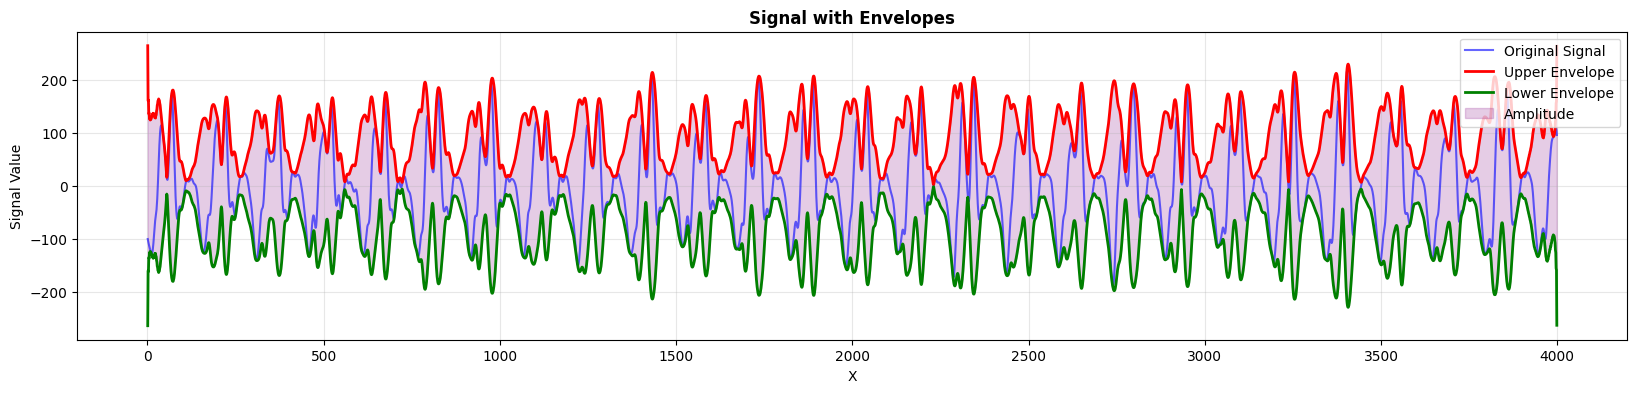

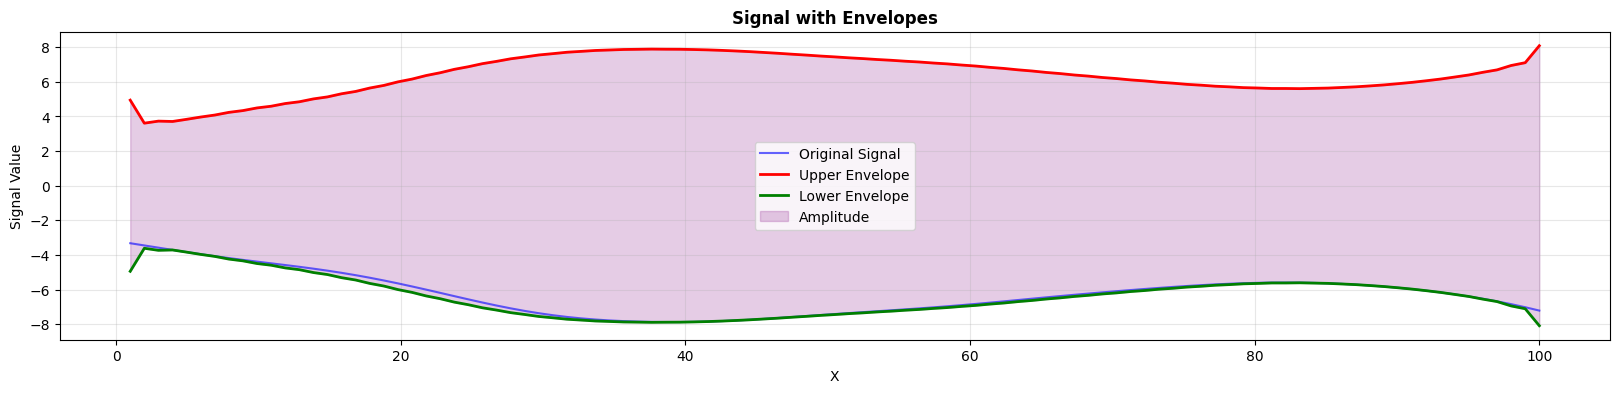

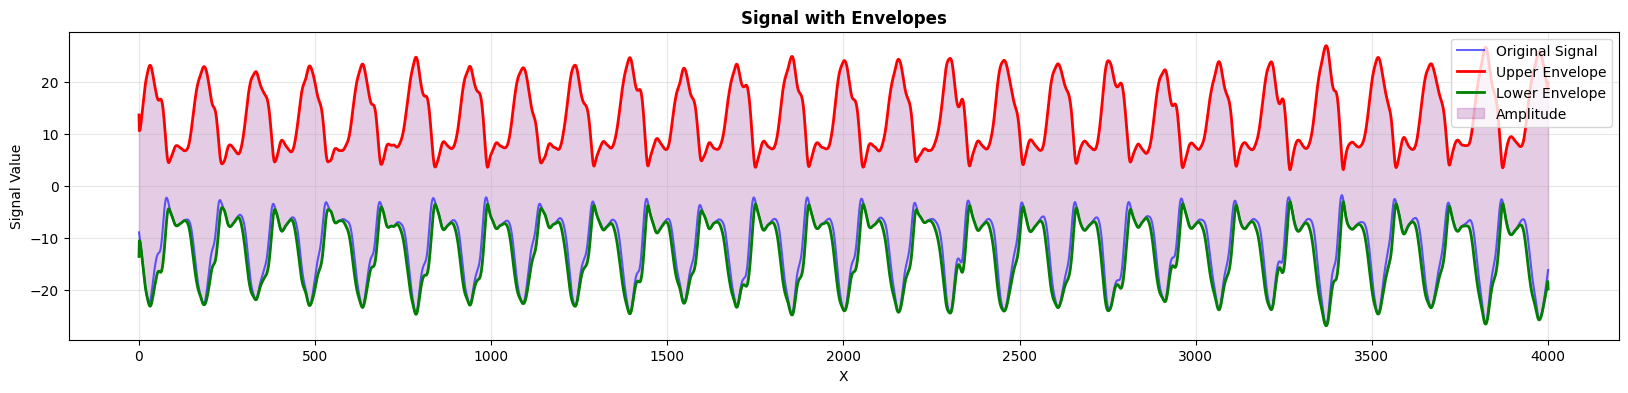

In [9]:
print("Testing envelope funciton using hilbert...")

for dataset, data in angles_velocity_data.items():
    envelope_metrics = get_envelope_metrics(data["x"], function=get_envelope_signal_hilbert)
    for metric, value in envelope_metrics.items():
        if metric not in ["upper_envelope_signal", "lower_envelope_signal", "amplitude_signal"]:
            print(f"{dataset} x-axis {metric}: {value}")
    plot_signal_with_envelopes(data["t"], data["x"], envelope_metrics["upper_envelope_signal"], envelope_metrics["lower_envelope_signal"])
    print("\n")

In [10]:
def get_envelope_signal_scipy(signal_1d, type: str):
    """
    Calculate upper or lower envelope using SciPy's built-in envelope function.
    
    SciPy's envelope function provides a clean, optimized implementation of 
    envelope detection using the Hilbert transform approach internally.
    
    Args:
        signal_1d: 1D array of signal values
        type: 'upper' for upper envelope, 'lower' for lower envelope
    
    Returns:
        envelope_signal: smooth envelope signal using SciPy's envelope function
    """
    x_env, x_res = envelope(signal_1d)
    if type == "upper":
        return x_res + x_env
        
    elif type == "lower":
        return x_res - x_env
        
    else:
        raise ValueError("Invalid type. Must be 'upper' or 'lower'.")


In [15]:

def get_envelope_signal_corrected(signal_1d, type: str):
    """
    Calculate upper or lower envelope using Hilbert transform - the correct approach.
    
    The Hilbert transform provides the analytical signal, from which we extract
    the instantaneous amplitude envelope that properly follows the signal's variations.
    
    Args:
        signal_1d: 1D array of signal values
        type: 'upper' for upper envelope, 'lower' for lower envelope
    
    Returns:
        envelope_signal: smooth envelope signal using Hilbert transform
    """
    if type == "upper":
        # For upper envelope, use the magnitude of the analytical signal
        analytical_signal = hilbert(signal_1d)
        envelope = np.abs(analytical_signal)
        return envelope
        
    elif type == "lower":
        # For lower envelope, invert signal, get envelope, then invert back
        analytical_signal = hilbert(-signal_1d)
        envelope = -np.abs(analytical_signal)
        return envelope
        
    else:
        raise ValueError("Invalid type. Must be 'upper' or 'lower'.")


In [18]:
# Now let's demonstrate the CORRECT envelope analysis for L_knee normalized velocity
print("=== CORRECTED ENVELOPE ANALYSIS FOR L_KNEE NORMALIZED VELOCITY ===")
print()

# Calculate envelopes using the correct Hilbert transform method
velocity_components = [
    (angles_velocity_data["Raw Velocity"]["x"], 'X'),
    (angles_velocity_data["Raw Velocity"]["y"], 'Y'), 
    (angles_velocity_data["Raw Velocity"]["z"], 'Z')
]

results_summary = []

for velocity, axis_name in velocity_components:
    # Calculate correct envelopes
    upper_envelope = get_envelope_signal_corrected(velocity, type="upper")
    lower_envelope = get_envelope_signal_corrected(velocity, type="lower")
    amplitude = upper_envelope - lower_envelope
    
    # Calculate statistics
    stats = {
        'axis': axis_name,
        'mean_amplitude': np.mean(amplitude),
        'max_amplitude': np.max(amplitude),
        'min_amplitude': np.min(amplitude),
        'std_amplitude': np.std(amplitude),
        'amplitude_range': np.max(amplitude) - np.min(amplitude)
    }
    
    results_summary.append(stats)
    
    print(f"{axis_name}-axis Results:")
    print(f"  Mean Amplitude: {stats['mean_amplitude']:.3f} deg/s")
    print(f"  Max Amplitude:  {stats['max_amplitude']:.3f} deg/s")
    print(f"  Min Amplitude:  {stats['min_amplitude']:.3f} deg/s")
    print(f"  Std Amplitude:  {stats['std_amplitude']:.3f} deg/s")
    print(f"  Range:          {stats['amplitude_range']:.3f} deg/s")
    print()

# Create summary DataFrame
final_summary_df = pd.DataFrame(results_summary)
print("FINAL ENVELOPE ANALYSIS SUMMARY:")
print("=" * 60)
print(final_summary_df.round(3))


=== CORRECTED ENVELOPE ANALYSIS FOR L_KNEE NORMALIZED VELOCITY ===

X-axis Results:
  Mean Amplitude: 190.745 deg/s
  Max Amplitude:  529.403 deg/s
  Min Amplitude:  4.219 deg/s
  Std Amplitude:  106.828 deg/s
  Range:          525.184 deg/s

Y-axis Results:
  Mean Amplitude: 296.429 deg/s
  Max Amplitude:  721.902 deg/s
  Min Amplitude:  5.393 deg/s
  Std Amplitude:  173.706 deg/s
  Range:          716.510 deg/s

Z-axis Results:
  Mean Amplitude: 1004.553 deg/s
  Max Amplitude:  2302.289 deg/s
  Min Amplitude:  415.271 deg/s
  Std Amplitude:  292.649 deg/s
  Range:          1887.018 deg/s

FINAL ENVELOPE ANALYSIS SUMMARY:
  axis  mean_amplitude  max_amplitude  min_amplitude  std_amplitude  \
0    X         190.745        529.403          4.219        106.828   
1    Y         296.429        721.902          5.393        173.706   
2    Z        1004.553       2302.289        415.271        292.649   

   amplitude_range  
0          525.184  
1          716.510  
2         1887.018  


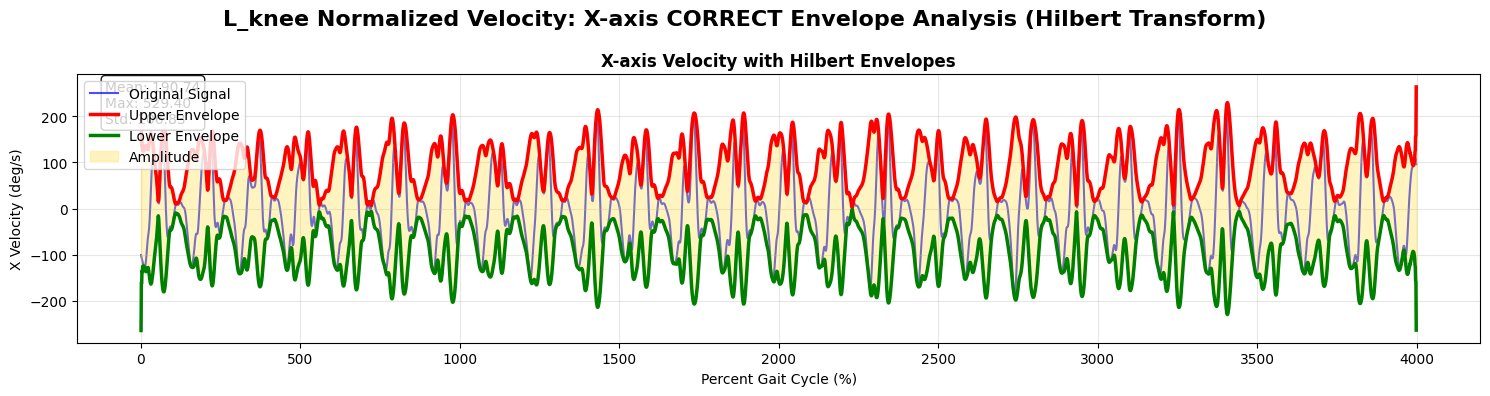

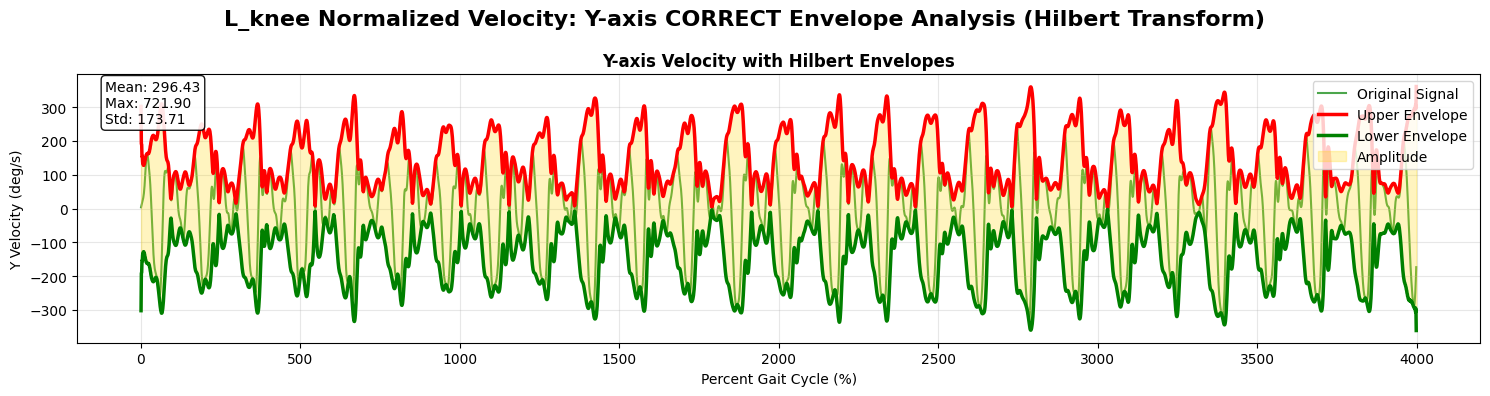

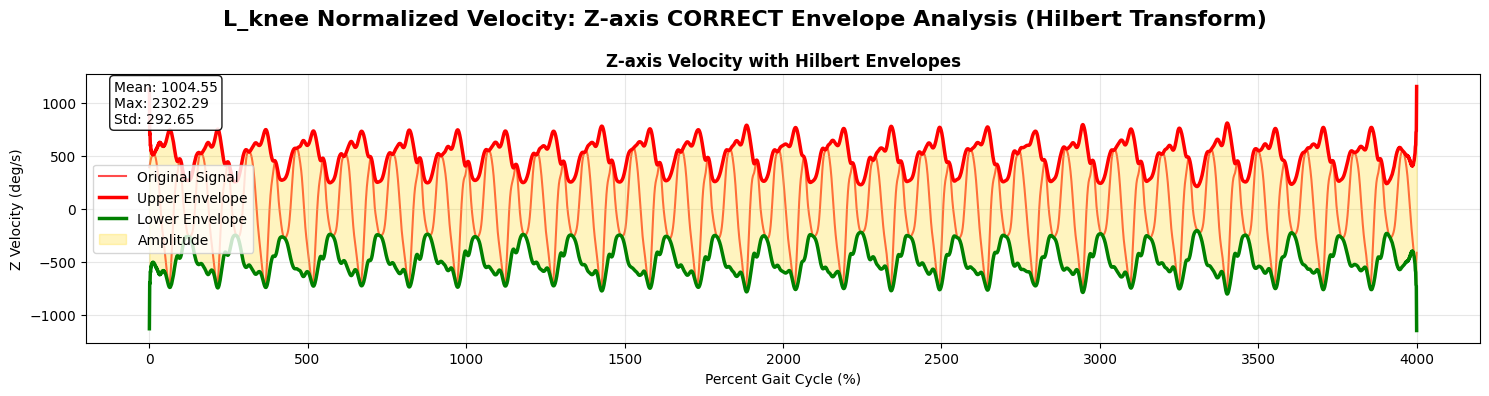

In [25]:
# Create final visualization with CORRECT envelope implementation
velocity_components = [
    (angles_velocity_data["Raw Velocity"]["x"], 'X', 'blue'),
    (angles_velocity_data["Raw Velocity"]["y"], 'Y', 'green'), 
    (angles_velocity_data["Raw Velocity"]["z"], 'Z', 'red')
]
t = angles_velocity_data["Raw Velocity"]["t"]

for velocity, axis_name, color in velocity_components:
    fig, ax = plt.subplots(figsize=(15, 4))
    fig.suptitle(f'L_knee Normalized Velocity: {axis_name}-axis CORRECT Envelope Analysis (Hilbert Transform)', 
                 fontsize=16, fontweight='bold')

    # Calculate correct envelopes
    upper_envelope = get_envelope_signal_corrected(velocity, type="upper")
    lower_envelope = get_envelope_signal_corrected(velocity, type="lower")
    amplitude = upper_envelope - lower_envelope

    # Plot original signal
    ax.plot(t, velocity, color=color, alpha=0.7, linewidth=1.5, 
            label='Original Signal', zorder=1)

    # Plot correct envelopes
    ax.plot(t, upper_envelope, color='red', linewidth=2.5, 
            label='Upper Envelope', zorder=3)
    ax.plot(t, lower_envelope, color='green', linewidth=2.5, 
            label='Lower Envelope', zorder=3)

    # Fill amplitude area
    ax.fill_between(t, lower_envelope, upper_envelope, 
                   alpha=0.25, color='gold', label='Amplitude', zorder=2)

    ax.set_title(f'{axis_name}-axis Velocity with Hilbert Envelopes', fontweight='bold')
    ax.set_xlabel('Percent Gait Cycle (%)')
    ax.set_ylabel(f'{axis_name} Velocity (deg/s)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add statistics
    mean_amp = np.mean(amplitude)
    max_amp = np.max(amplitude)
    std_amp = np.std(amplitude)

    stats_text = f'Mean: {mean_amp:.2f}\nMax: {max_amp:.2f}\nStd: {std_amp:.2f}'
    ax.text(0.02, 0.98, stats_text, 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            fontsize=10)

    plt.tight_layout()
    plt.show()

In [29]:
# Add spline-based envelope function using local maxima/minima
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline

def get_envelope_signal_spline(signal_1d, type: str, x_values=None, smoothing_factor=0):
    """
    Calculate upper or lower envelope using local maxima/minima and spline interpolation.
    
    This approach:
    1. Finds local maxima (peaks) or minima (troughs) in the signal
    2. Adds endpoint handling for complete envelope coverage
    3. Uses spline interpolation for smooth envelope curves
    
    Args:
        signal_1d: 1D array of signal values
        type: 'upper' for upper envelope, 'lower' for lower envelope
        x_values: x-axis values (optional, uses indices if None)
        smoothing_factor: spline smoothing parameter (0 = interpolating spline)
    
    Returns:
        envelope_signal: smooth envelope signal using spline interpolation
    """
    if x_values is None:
        x_values = np.arange(len(signal_1d))
    
    if type == "upper":
        # Find peaks (local maxima) for upper envelope
        peak_indices, _ = find_peaks(signal_1d)
        
        # Add endpoints if they are appropriate maxima
        envelope_indices = list(peak_indices)
        if len(signal_1d) > 1:
            # Add first point if it's a local maximum or equal to neighbor
            if signal_1d[0] >= signal_1d[1]:
                envelope_indices.insert(0, 0)
            # Add last point if it's a local maximum or equal to neighbor  
            if signal_1d[-1] >= signal_1d[-2]:
                envelope_indices.append(len(signal_1d) - 1)
        elif len(signal_1d) == 1:
            envelope_indices = [0]
            
    elif type == "lower":
        # Find troughs (local minima) for lower envelope
        trough_indices, _ = find_peaks(-signal_1d)
        
        # Add endpoints if they are appropriate minima
        envelope_indices = list(trough_indices)
        if len(signal_1d) > 1:
            # Add first point if it's a local minimum or equal to neighbor
            if signal_1d[0] <= signal_1d[1]:
                envelope_indices.insert(0, 0)
            # Add last point if it's a local minimum or equal to neighbor
            if signal_1d[-1] <= signal_1d[-2]:
                envelope_indices.append(len(signal_1d) - 1)
        elif len(signal_1d) == 1:
            envelope_indices = [0]
            
    else:
        raise ValueError("Invalid type. Must be 'upper' or 'lower'.")
    
    # Remove duplicates and sort
    envelope_indices = sorted(list(set(envelope_indices)))
    
    # Handle edge cases
    if len(envelope_indices) == 0:
        # No extrema found - return constant envelope
        if type == "upper":
            return np.full_like(signal_1d, np.max(signal_1d))
        else:
            return np.full_like(signal_1d, np.min(signal_1d))
    
    elif len(envelope_indices) == 1:
        # Only one extremum - return constant envelope at that value
        return np.full_like(signal_1d, signal_1d[envelope_indices[0]])
    
    elif len(envelope_indices) == 2:
        # Two points - use linear interpolation
        from scipy.interpolate import interp1d
        linear_interp = interp1d(x_values[envelope_indices], signal_1d[envelope_indices], 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
        return linear_interp(x_values)
    
    else:
        # Multiple points - use spline interpolation
        try:
            # Create spline interpolator
            spline = UnivariateSpline(x_values[envelope_indices], signal_1d[envelope_indices], 
                                    s=smoothing_factor, k=min(3, len(envelope_indices)-1))
            envelope_signal = spline(x_values)
            return envelope_signal
            
        except Exception:
            # Fallback to linear interpolation if spline fails
            from scipy.interpolate import interp1d
            linear_interp = interp1d(x_values[envelope_indices], signal_1d[envelope_indices], 
                                   kind='linear', bounds_error=False, fill_value='extrapolate')
            return linear_interp(x_values)

In [35]:
# Compare all three envelope methods: Peak-based, Hilbert Transform, and Spline-based
print("=== COMPARING ALL THREE ENVELOPE METHODS ===")
print()

x_velocity = angles_velocity_data["Raw Velocity"]["x"]
t = angles_velocity_data["Raw Velocity"]["t"]

# Test all three methods on X-axis velocity
x_upper_peaks = get_envelope_signal_via_peaks(x_velocity, type="upper")
x_lower_peaks = get_envelope_signal_via_peaks(x_velocity, type="lower")

x_upper_hilbert = get_envelope_signal_corrected(x_velocity, type="upper")
x_lower_hilbert = get_envelope_signal_corrected(x_velocity, type="lower")

x_upper_spline = get_envelope_signal_spline(x_velocity, type="upper", x_values=t)
x_lower_spline = get_envelope_signal_spline(x_velocity, type="lower", x_values=t)

# Calculate amplitudes
amplitude_peaks = x_upper_peaks - x_lower_peaks
amplitude_hilbert = x_upper_hilbert - x_lower_hilbert
amplitude_spline = x_upper_spline - x_lower_spline

print("X-axis Amplitude Statistics Comparison:")
print()
print("1. Peak-based (Linear Interpolation):")
print(f"   Mean: {np.mean(amplitude_peaks):.3f} deg/s")
print(f"   Max:  {np.max(amplitude_peaks):.3f} deg/s")
print(f"   Std:  {np.std(amplitude_peaks):.3f} deg/s")
print()

print("2. Hilbert Transform:")
print(f"   Mean: {np.mean(amplitude_hilbert):.3f} deg/s")
print(f"   Max:  {np.max(amplitude_hilbert):.3f} deg/s")
print(f"   Std:  {np.std(amplitude_hilbert):.3f} deg/s")
print()

print("3. Spline-based (Peak Detection + Spline Interpolation):")
print(f"   Mean: {np.mean(amplitude_spline):.3f} deg/s")
print(f"   Max:  {np.max(amplitude_spline):.3f} deg/s")
print(f"   Std:  {np.std(amplitude_spline):.3f} deg/s")
print()

# Check how many peaks/troughs were detected for spline method
x_peaks, _ = find_peaks(x_velocity)
x_troughs, _ = find_peaks(-x_velocity)
print(f"Spline method detected: {len(x_peaks)} peaks and {len(x_troughs)} troughs")


=== COMPARING ALL THREE ENVELOPE METHODS ===

X-axis Amplitude Statistics Comparison:

1. Peak-based (Linear Interpolation):
   Mean: 104.063 deg/s
   Max:  272.943 deg/s
   Std:  64.840 deg/s

2. Hilbert Transform:
   Mean: 190.745 deg/s
   Max:  529.403 deg/s
   Std:  106.828 deg/s

3. Spline-based (Peak Detection + Spline Interpolation):
   Mean: 94.118 deg/s
   Max:  285.048 deg/s
   Std:  73.791 deg/s

Spline method detected: 133 peaks and 133 troughs


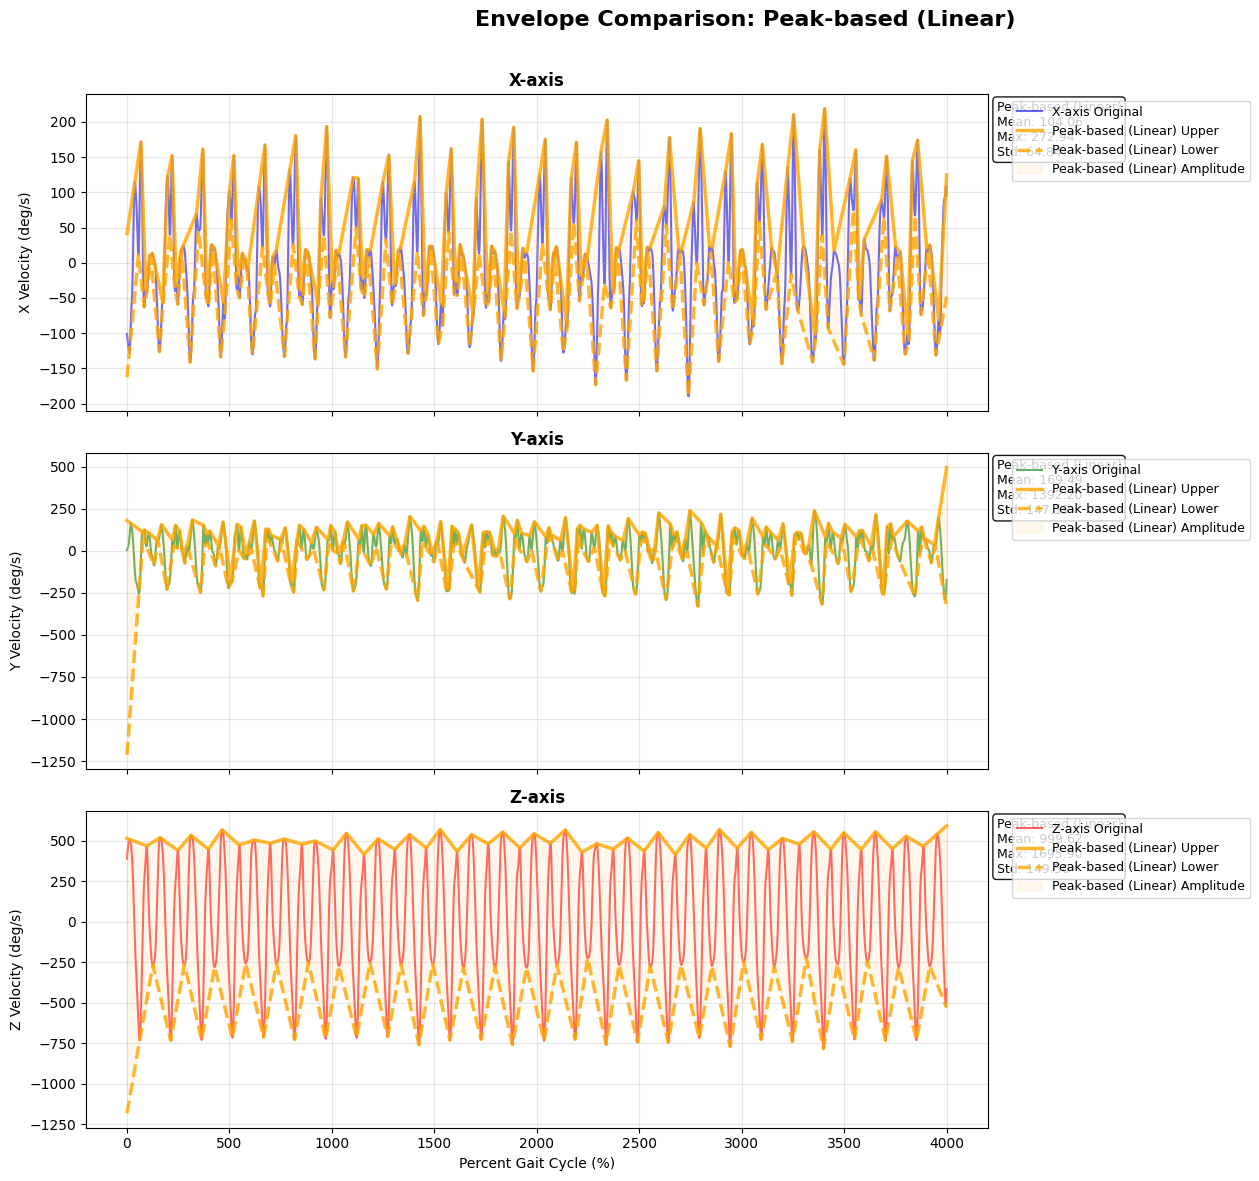

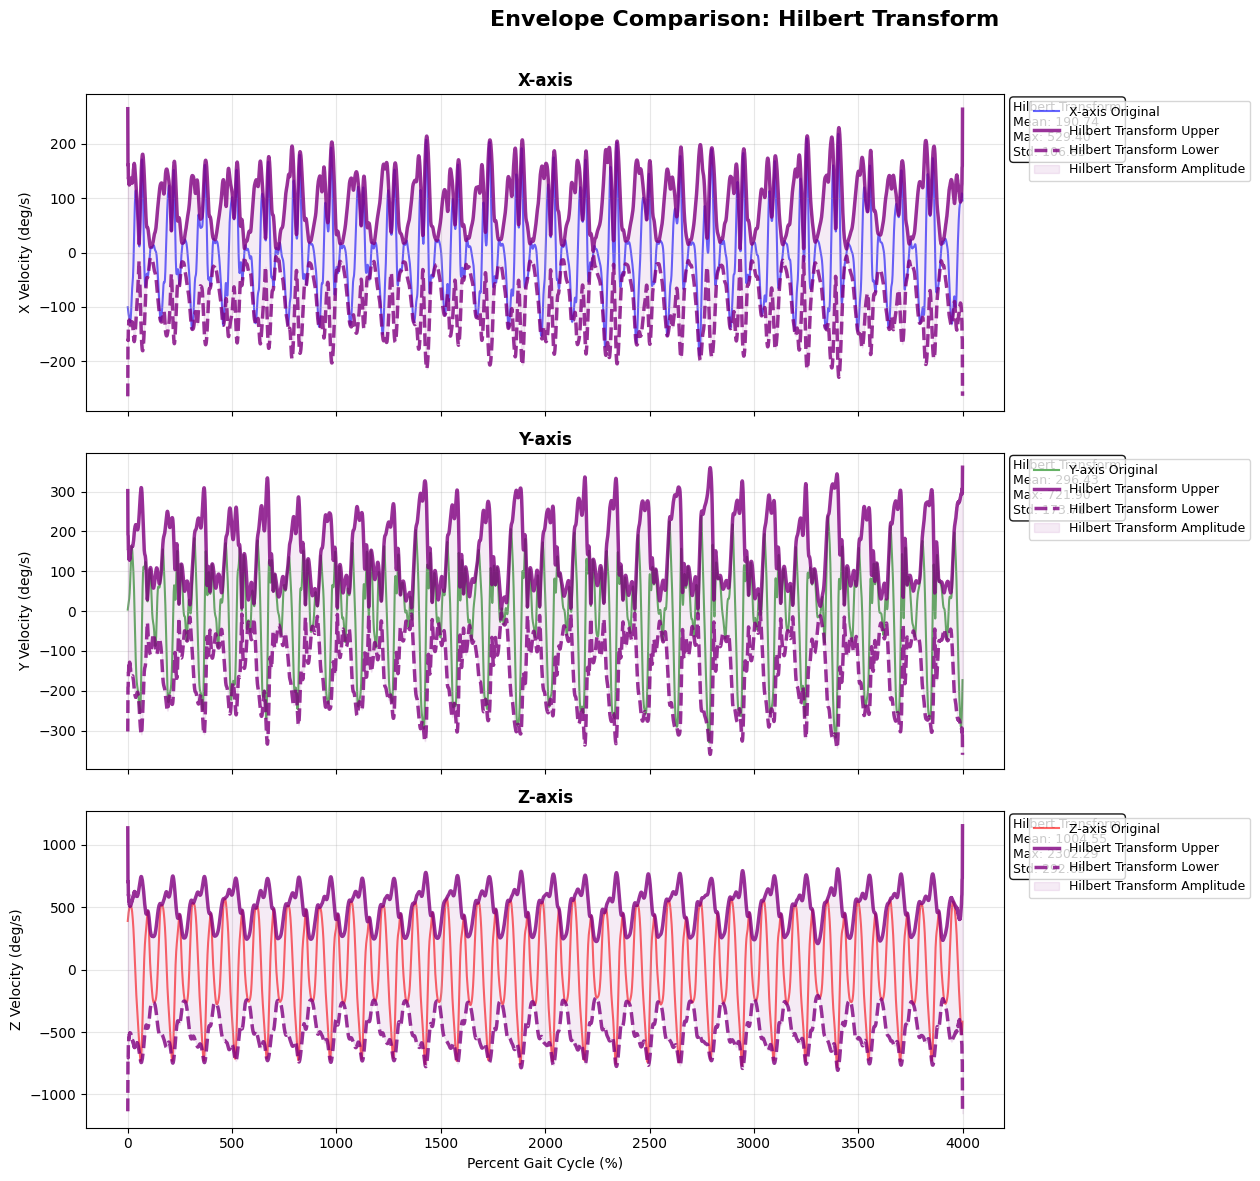

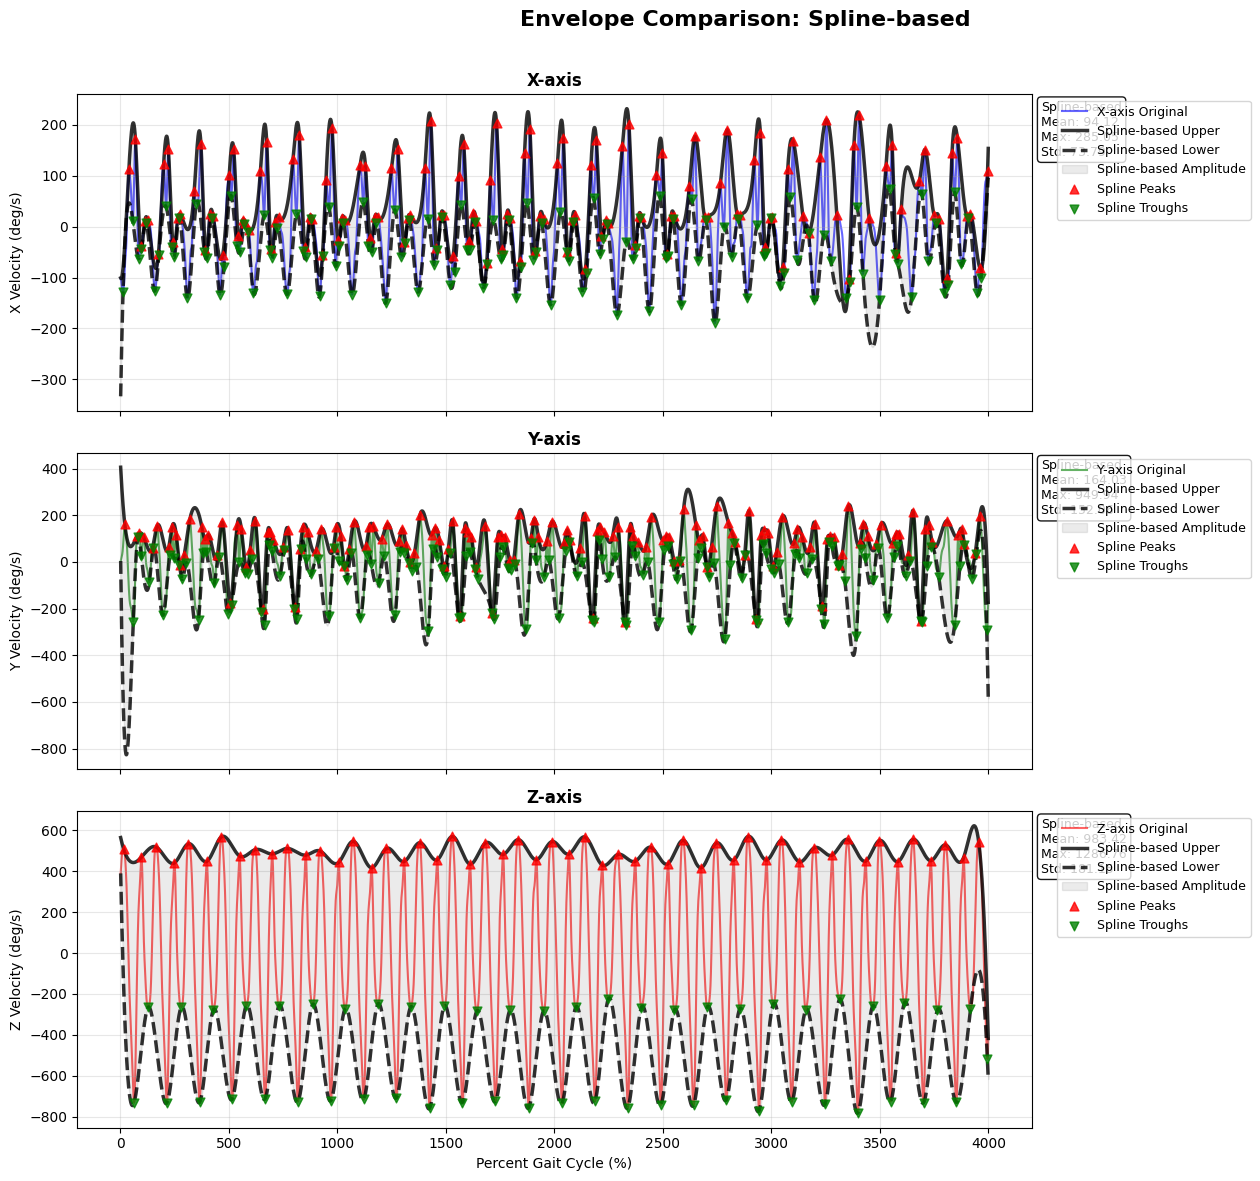

In [41]:
# One plot per function: create a separate figure for each envelope method, showing all three axes
x_velocity = angles_velocity_data["Raw Velocity"]["x"]
y_velocity = angles_velocity_data["Raw Velocity"]["y"]
z_velocity = angles_velocity_data["Raw Velocity"]["z"]
t = angles_velocity_data["Raw Velocity"]["t"]

velocity_components = [
    (x_velocity, 'X', 'blue'),
    (y_velocity, 'Y', 'green'), 
    (z_velocity, 'Z', 'red')
]

method_names = ['Peak-based (Linear)', 'Hilbert Transform', 'Spline-based']
method_functions = [get_envelope_signal_via_peaks, get_envelope_signal_corrected, get_envelope_signal_spline]
method_colors = ['orange', 'purple', 'black']

for method_name, method_func, method_color in zip(method_names, method_functions, method_colors):
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f'Envelope Comparison: {method_name}', fontsize=16, fontweight='bold')
    for i, (velocity, axis_name, color) in enumerate(velocity_components):
        ax = axes[i]
        # Calculate envelopes using current method
        if method_func == get_envelope_signal_spline:
            upper_envelope = method_func(velocity, type="upper", x_values=t)
            lower_envelope = method_func(velocity, type="lower", x_values=t)
        else:
            upper_envelope = method_func(velocity, type="upper")
            lower_envelope = method_func(velocity, type="lower")
        amplitude = upper_envelope - lower_envelope

        # Plot original signal
        ax.plot(t, velocity, color=color, alpha=0.6, linewidth=1.5, 
                label=f'{axis_name}-axis Original', zorder=1)
        # Plot envelopes
        ax.plot(t, upper_envelope, color=method_color, linewidth=2.5, 
                label=f'{method_name} Upper', zorder=3, alpha=0.8)
        ax.plot(t, lower_envelope, color=method_color, linewidth=2.5, 
                linestyle='--', label=f'{method_name} Lower', zorder=3, alpha=0.8)
        # Fill amplitude area (light color)
        ax.fill_between(t, lower_envelope, upper_envelope, 
                       alpha=0.08, color=method_color, label=f'{method_name} Amplitude', zorder=2)

        # Mark peaks and troughs for spline method
        if method_func == get_envelope_signal_spline:
            peaks, _ = find_peaks(velocity)
            troughs, _ = find_peaks(-velocity)
            if len(peaks) > 0:
                ax.scatter(t[peaks], velocity[peaks], 
                          color='red', s=40, marker='^', zorder=4, alpha=0.8, label='Spline Peaks')
            if len(troughs) > 0:
                ax.scatter(t[troughs], velocity[troughs], 
                          color='green', s=40, marker='v', zorder=4, alpha=0.8, label='Spline Troughs')

        # Add statistics for each method
        mean_amp = np.mean(amplitude)
        max_amp = np.max(amplitude)
        std_amp = np.std(amplitude)
        stats_text = f'{method_name}\nMean: {mean_amp:.2f}\nMax: {max_amp:.2f}\nStd: {std_amp:.2f}'
        ax.text(1.01, 0.98, stats_text, 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                fontsize=9)

        ax.set_title(f'{axis_name}-axis', fontweight='bold')
        ax.set_ylabel(f'{axis_name} Velocity (deg/s)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    axes[-1].set_xlabel('Percent Gait Cycle (%)')
    plt.tight_layout(rect=[0, 0, 0.85, 0.97])
    plt.show()


In [45]:
# Create final comprehensive analysis of all three methods
print("=== COMPREHENSIVE ENVELOPE METHOD ANALYSIS ===")
print()

method_results = []

velocity_components = [
    (x_velocity, 'X'),
    (y_velocity, 'Y'), 
    (z_velocity, 'Z')
]

for velocity, axis_name in velocity_components:
    # Calculate envelopes using all three methods
    upper_peaks = get_envelope_signal_via_peaks(velocity, type="upper")
    lower_peaks = get_envelope_signal_via_peaks(velocity, type="lower")
    amplitude_peaks = upper_peaks - lower_peaks
    
    upper_hilbert = get_envelope_signal_corrected(velocity, type="upper")
    lower_hilbert = get_envelope_signal_corrected(velocity, type="lower")
    amplitude_hilbert = upper_hilbert - lower_hilbert
    
    upper_spline = get_envelope_signal_spline(velocity, type="upper", x_values=t)
    lower_spline = get_envelope_signal_spline(velocity, type="lower", x_values=t)
    amplitude_spline = upper_spline - lower_spline
    
    # Count peaks/troughs for spline method
    peaks, _ = find_peaks(velocity)
    troughs, _ = find_peaks(-velocity)
    
    # Store results
    result = {
        'axis': axis_name,
        'peaks_mean': np.mean(amplitude_peaks),
        'peaks_max': np.max(amplitude_peaks),
        'peaks_std': np.std(amplitude_peaks),
        'hilbert_mean': np.mean(amplitude_hilbert),
        'hilbert_max': np.max(amplitude_hilbert),
        'hilbert_std': np.std(amplitude_hilbert),
        'spline_mean': np.mean(amplitude_spline),
        'spline_max': np.max(amplitude_spline),
        'spline_std': np.std(amplitude_spline),
        'num_peaks': len(peaks),
        'num_troughs': len(troughs)
    }
    
    method_results.append(result)
    
    print(f"{axis_name}-axis Summary:")
    print(f"  Peak-based:    Mean={result['peaks_mean']:.3f}, Max={result['peaks_max']:.3f}, Std={result['peaks_std']:.3f}")
    print(f"  Hilbert:       Mean={result['hilbert_mean']:.3f}, Max={result['hilbert_max']:.3f}, Std={result['hilbert_std']:.3f}")
    print(f"  Spline-based:  Mean={result['spline_mean']:.3f}, Max={result['spline_max']:.3f}, Std={result['spline_std']:.3f}")
    print(f"  Extrema found: {result['num_peaks']} peaks, {result['num_troughs']} troughs")


=== COMPREHENSIVE ENVELOPE METHOD ANALYSIS ===

X-axis Summary:
  Peak-based:    Mean=104.063, Max=272.943, Std=64.840
  Hilbert:       Mean=190.745, Max=529.403, Std=106.828
  Spline-based:  Mean=94.118, Max=285.048, Std=73.791
  Extrema found: 133 peaks, 133 troughs
Y-axis Summary:
  Peak-based:    Mean=169.492, Max=1392.196, Std=147.187
  Hilbert:       Mean=296.429, Max=721.902, Std=173.706
  Spline-based:  Mean=164.032, Max=949.942, Std=152.062
  Extrema found: 149 peaks, 149 troughs
Z-axis Summary:
  Peak-based:    Mean=999.615, Max=1695.900, Std=149.498
  Hilbert:       Mean=1004.553, Max=2302.289, Std=292.649
  Spline-based:  Mean=983.417, Max=1286.764, Std=181.149
  Extrema found: 53 peaks, 53 troughs


Testing envelope funciton using Scipy's Envelope function...


Normalized Velocity x-axis mean_upper: -3.040141827911777
Normalized Velocity x-axis mean_lower: -10.164099426615088
Normalized Velocity x-axis mean_amplitude: 7.123957598703311
Normalized Velocity x-axis max_upper: 24.205779228613537
Normalized Velocity x-axis max_lower: 46.86071482761645
Normalized Velocity x-axis max_amplitude: 45.397621257838985


Raw Velocity x-axis mean_upper: 46.84130373384929
Raw Velocity x-axis mean_lower: -47.27650049758397
Raw Velocity x-axis mean_amplitude: 94.11780423143324
Raw Velocity x-axis max_upper: 231.6541794771805
Raw Velocity x-axis max_lower: 95.9140643990146
Raw Velocity x-axis max_amplitude: 285.0481883326525


Normalized Angle x-axis mean_upper: -4.703150187643493
Normalized Angle x-axis mean_lower: -7.7461403584608375
Normalized Angle x-axis mean_amplitude: 3.042990170817345
Normalized Angle x-axis max_upper: -3.31830732216798
Normalized Angle x-axis max_lower: -7.20504870062464
N

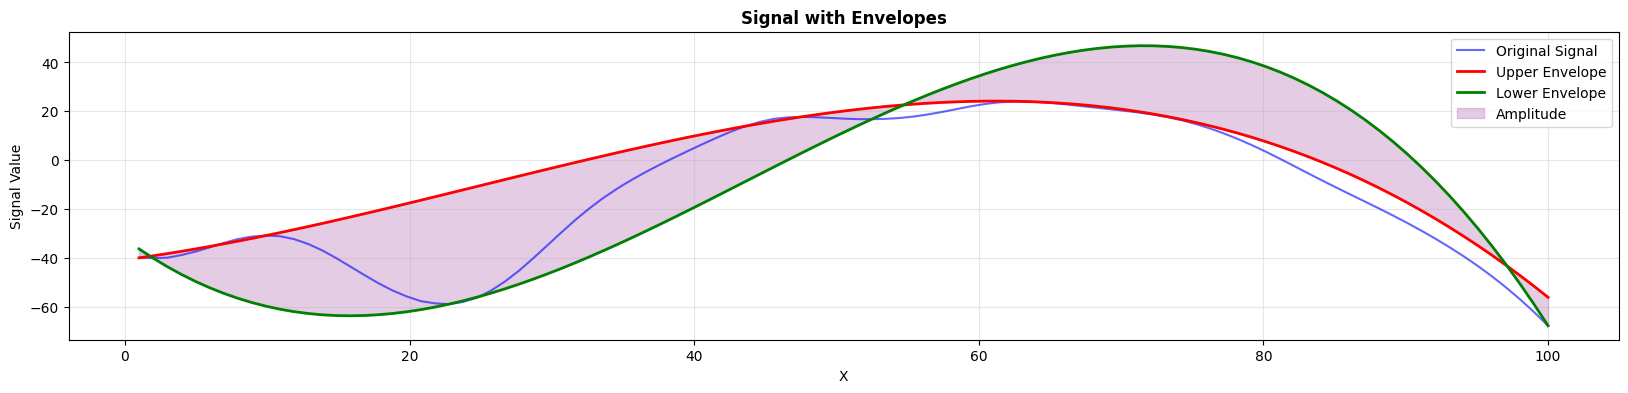

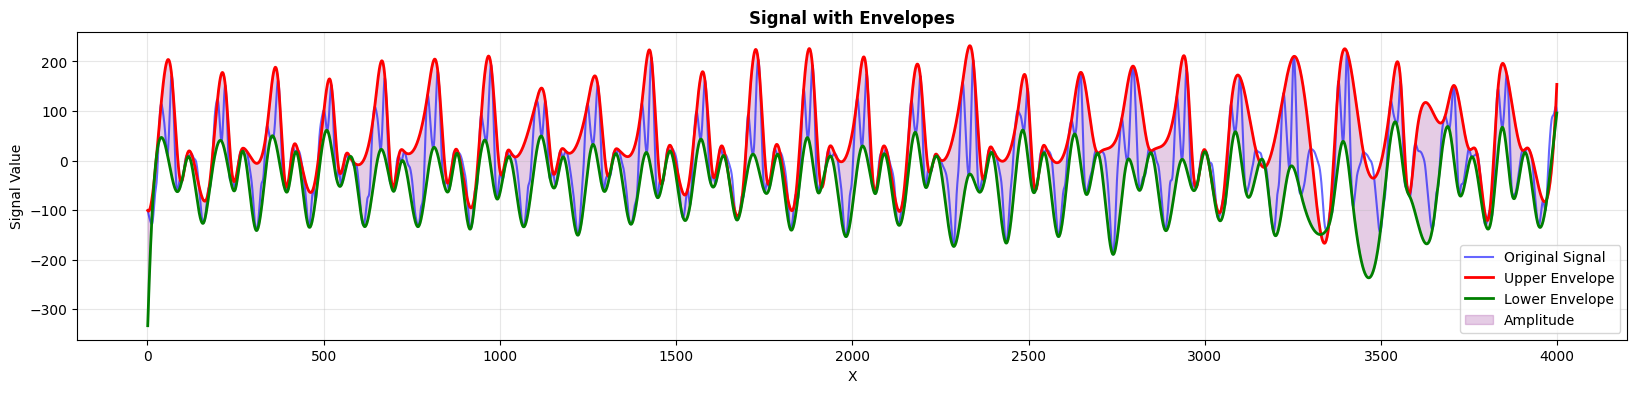

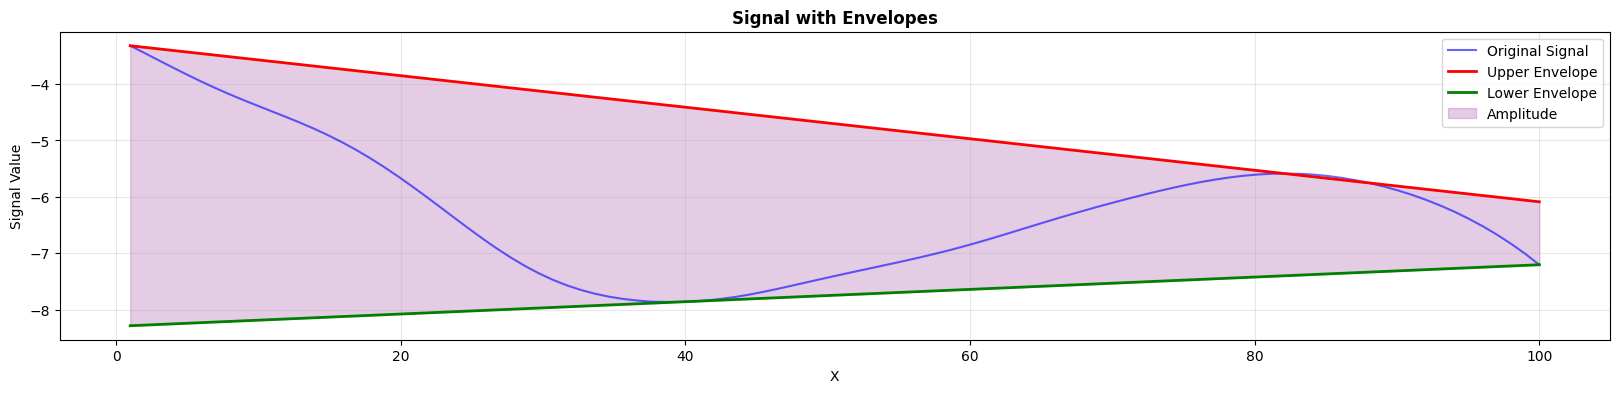

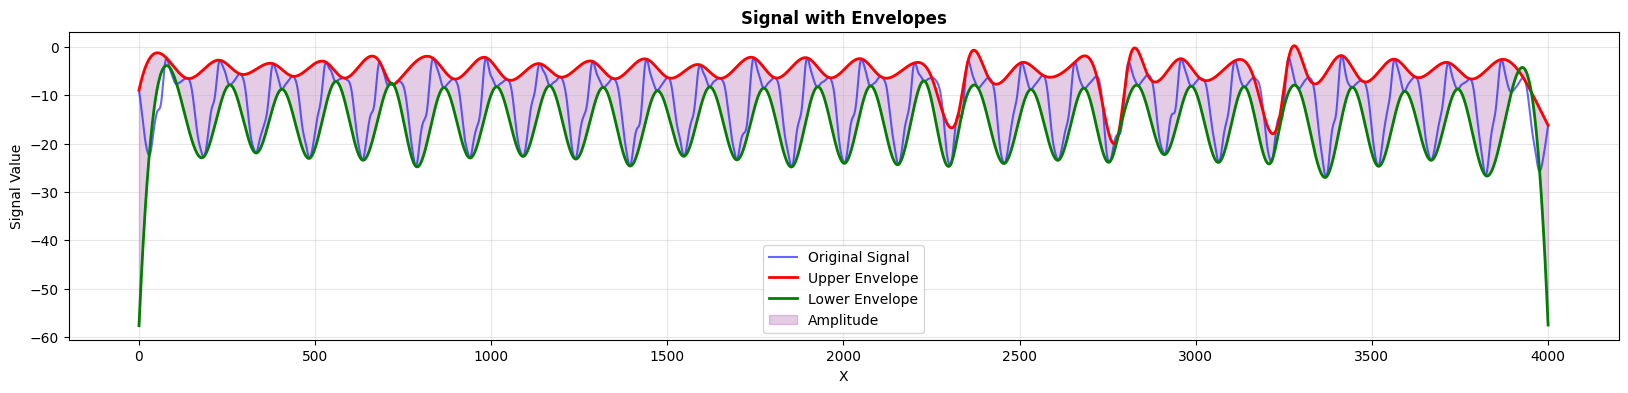

In [46]:
print("Testing envelope funciton using Scipy's Envelope function...")
print("\n")


for dataset, data in angles_velocity_data.items():
    envelope_metrics = get_envelope_metrics(data["x"], function=get_envelope_signal_spline)
    for metric, value in envelope_metrics.items():
        if metric not in ["upper_envelope_signal", "lower_envelope_signal", "amplitude_signal"]:
            print(f"{dataset} x-axis {metric}: {value}")
    plot_signal_with_envelopes(data["t"], data["x"], envelope_metrics["upper_envelope_signal"], envelope_metrics["lower_envelope_signal"])
    print("\n")

### Hilbert Transform for Envelope calculation:

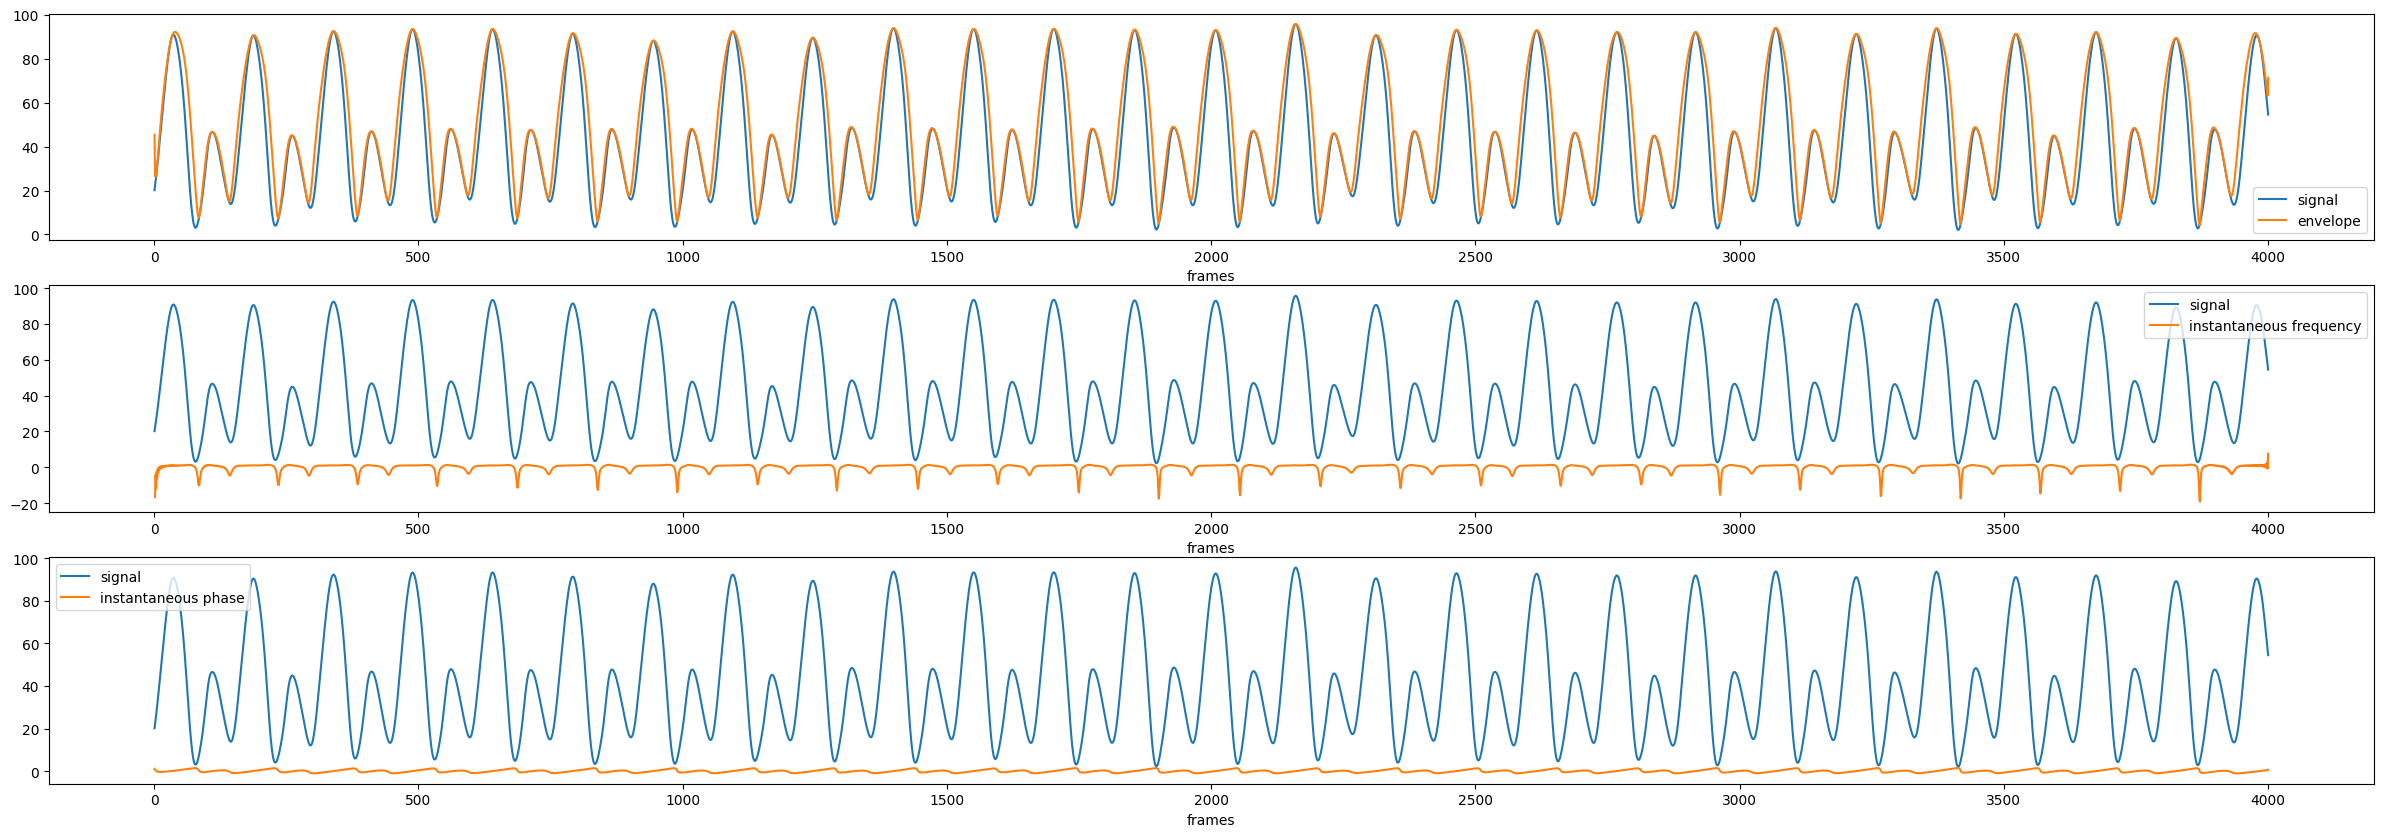

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert


x_velocity = angles_velocity_data["Raw Angle"]["x"]
y_velocity = angles_velocity_data["Raw Angle"]["y"]
z_velocity = angles_velocity_data["Raw Angle"]["z"]
t = angles_velocity_data["Raw Angle"]["t"]

fs = 200
signal = z_velocity

analytic_signal = hilbert(signal)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
instantaneous_frequency = np.diff(instantaneous_phase) / (2.0*np.pi) * fs

fig = plt.figure(figsize=(30, 10))
ax0 = fig.add_subplot(311)
ax0.plot(t, signal, label='signal')
ax0.plot(t, amplitude_envelope, label='envelope')
ax0.set_xlabel("frames")
ax0.legend()
ax1 = fig.add_subplot(312)
ax1.plot(t, signal, label='signal')
ax1.plot(t[1:], instantaneous_frequency, label='instantaneous frequency')
ax1.set_xlabel("frames")
ax1.legend()
ax2 = fig.add_subplot(313)
ax2.plot(t, signal, label='signal')
ax2.plot(t, instantaneous_phase, label='instantaneous phase')
ax2.set_xlabel("frames")
ax2.legend()

In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
stance_percent = np.linspace(0, 100, 101)

plane_names = ['X (Frontal)', 'Y (Transverse)', 'Z (Sagittal)']
colors = ['red', 'green', 'blue']

for axis in range(3):
    ax = axes[axis]
    
    # Plot individual cycles (faded)
    for cycle in range(normalized_phases.shape[1]):
        ax.plot(stance_percent, normalized_phases[:, cycle, axis], 
               color=colors[axis], alpha=0.1, linewidth=0.5)
    
    # Plot mean angles
    ax.plot(stance_percent, envelope_stats['mean_angles'][:, axis], 
           color=colors[axis], linewidth=3, label='Mean Angle')
    
    # Plot upper and lower envelopes (min/max)
    ax.plot(stance_percent, envelope_stats['upper_envelope'][:, axis], 
           color=colors[axis], linestyle='--', linewidth=2, label='Upper Envelope (Max)')
    ax.plot(stance_percent, envelope_stats['lower_envelope'][:, axis], 
           color=colors[axis], linestyle='--', linewidth=2, label='Lower Envelope (Min)')
    
    # Fill between envelopes
    ax.fill_between(stance_percent, 
                   envelope_stats['lower_envelope'][:, axis],
                   envelope_stats['upper_envelope'][:, axis],
                   color=colors[axis], alpha=0.2)
    
    # Plot mean ± std envelopes (alternative approach)
    ax.plot(stance_percent, envelope_stats['upper_envelope_std'][:, axis], 
           color=colors[axis], linestyle=':', linewidth=1.5, alpha=0.7, label='Mean + STD')
    ax.plot(stance_percent, envelope_stats['lower_envelope_std'][:, axis], 
           color=colors[axis], linestyle=':', linewidth=1.5, alpha=0.7, label='Mean - STD')
    
    ax.set_xlabel('Stance Phase (%)')
    ax.set_ylabel(f'Angle {plane_names[axis]} (degrees)')
    ax.set_title(f'Joint Angles - {plane_names[axis]} Plane')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== ENVELOPE ANALYSIS SUMMARY ===")
for axis, plane in enumerate(plane_names):
    mean_range = np.ptp(envelope_stats['mean_angles'][:, axis])
    envelope_range = (np.ptp(envelope_stats['upper_envelope'][:, axis]) + 
                     np.ptp(envelope_stats['lower_envelope'][:, axis])) / 2
    
    print(f"\n{plane} Plane:")
    print(f"  Mean angle range: {mean_range:.2f}°")
    print(f"  Average envelope range: {envelope_range:.2f}°")
    print(f"  Max envelope width: {np.max(envelope_stats['upper_envelope'][:, axis] - envelope_stats['lower_envelope'][:, axis]):.2f}°")

## Explanation: Computing Upper and Lower Envelope Angles

This notebook demonstrates how to compute the **time series objects** mentioned in biomechanical gait analysis studies:

> *"The time series used in this study are the mean angles and the upper-and lower-envelope angles during the stance phase of the segmented strides."*

### What We're Computing:

1. **Mean Angles**: The average joint angle trajectory across all stance phases
2. **Upper Envelope**: The maximum angle values at each percentage of stance phase
3. **Lower Envelope**: The minimum angle values at each percentage of stance phase

### The Process:

1. **Stance Phase Segmentation**: Extract individual stance phases from touchdown to toe-off
2. **Time Normalization**: Normalize each stance phase to 0-100% (101 points)
3. **Statistical Analysis**: Compute mean, max, min across all normalized cycles

### Key Differences from Hilbert Transform:

- **Hilbert Transform** (your previous code): Analyzes signal modulation, frequency content, and instantaneous amplitude
- **Envelope Analysis** (this approach): Analyzes biomechanical variability and typical movement patterns during gait

### Applications:

- **Clinical Gait Analysis**: Comparing patient patterns to normative data
- **Injury Assessment**: Identifying abnormal movement patterns
- **Performance Analysis**: Understanding movement consistency and variability

The upper and lower envelopes capture the **natural variability** in joint motion across multiple gait cycles, which is crucial for understanding normal vs. pathological movement patterns.